# Zero-Stockout AI System — TFT Demand Forecasting Pipeline
CPU only, no GPU. Filtered to 3 stores x 30 products to stay memory-safe on Colab.

## Setup

In [1]:
import torch
import torch._dynamo
print(torch.__version__)

2.10.0+cu128


In [2]:
!pip install -q --no-deps "lightning<2.6" pytorch-forecasting kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 25.6 MB/s eta 0:00:00


In [3]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

torch.set_num_threads(os.cpu_count())
pd.set_option('display.max_columns', None)

# Stage 1 — Data Preparation

Download the DEPI Dataset

In [4]:
import kagglehub

path = kagglehub.dataset_download("davidhalim2004/depi-dataset")
csv_path = os.path.join(path, "data.csv")
print(csv_path)
print(os.path.exists(csv_path))

/kaggle/input/datasets/davidhalim2004/depi-dataset/data.csv
True


Read the Data and Understand the Columns

In [5]:
df_sample = pd.read_csv(csv_path, nrows=100000)
print(df_sample.shape)
print(df_sample.columns.tolist())
print(df_sample.dtypes)
df_sample.head()

(100000, 21)
['store_id', 'sales', 'wm_yr_wk', 'wday', 'snap', 'year', 'month', 'day', 'lag_1', 'item_category', 'item_subcategory', 'item_number', 'sell_price', 'price_flag', 'is_weekend', 'snap_weekend', 'wday_x_snap', 'lag_7', 'is_event', 'event_count', 'event_impact']
store_id             object
sales                 int64
wm_yr_wk              int64
wday                  int64
snap                  int64
year                  int64
month                 int64
day                   int64
lag_1                 int64
item_category        object
item_subcategory      int64
item_number           int64
sell_price          float64
price_flag            int64
is_weekend            int64
snap_weekend          int64
wday_x_snap           int64
lag_7                 int64
is_event              int64
event_count           int64
event_impact        float64
dtype: object


,store_id,sales,wm_yr_wk,wday,snap,year,month,day,lag_1,item_category,item_subcategory,item_number,sell_price,price_flag,is_weekend,snap_weekend,wday_x_snap,lag_7,is_event,event_count,event_impact
0,CA_1,3,1,1,0,2011,1,29,1,FOODS,1,1,2.0,0,1,0,0,0,0,0,0.0
1,CA_1,0,1,2,0,2011,1,30,3,FOODS,1,1,2.0,0,1,0,0,0,0,0,0.0
2,CA_1,0,1,3,0,2011,1,31,0,FOODS,1,1,2.0,0,0,0,0,0,0,0,0.0
3,CA_1,1,1,4,1,2011,2,1,0,FOODS,1,1,2.0,0,0,0,4,0,0,0,1.0
4,CA_1,4,1,5,1,2011,2,2,1,FOODS,1,1,2.0,0,0,0,5,0,0,0,4.0


Check the Data (shape / info / dtypes)

In [6]:
print(df_sample.shape)
df_sample.info()

(100000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   store_id          100000 non-null  object 
 1   sales             100000 non-null  int64  
 2   wm_yr_wk          100000 non-null  int64  
 3   wday              100000 non-null  int64  
 4   snap              100000 non-null  int64  
 5   year              100000 non-null  int64  
 6   month             100000 non-null  int64  
 7   day               100000 non-null  int64  
 8   lag_1             100000 non-null  int64  
 9   item_category     100000 non-null  object 
 10  item_subcategory  100000 non-null  int64  
 11  item_number       100000 non-null  int64  
 12  sell_price        100000 non-null  float64
 13  price_flag        100000 non-null  int64  
 14  is_weekend        100000 non-null  int64  
 15  snap_weekend      100000 non-null  int64  
 16  wday_x_s

Check Missing Values

In [7]:
print(df_sample.isnull().sum())

store_id            0
sales               0
wm_yr_wk            0
wday                0
snap                0
year                0
month               0
day                 0
lag_1               0
item_category       0
item_subcategory    0
item_number         0
sell_price          0
price_flag          0
is_weekend          0
snap_weekend        0
wday_x_snap         0
lag_7               0
is_event            0
event_count         0
event_impact        0
dtype: int64


check duplicates

In [8]:
print(df_sample.duplicated().sum())
print(df_sample.duplicated(subset=['store_id', 'item_number', 'year', 'month', 'day']).sum())

0
0


**Memory constraints:** We'll read the data in full, but filter it down to 3 stores and 30 products as we read it, so the model can run on CPU without crashing.

In [9]:
SELECTED_STORES = ['CA_1', 'TX_1', 'WI_1']
N_ITEMS = 30
MAX_ENCODER_LENGTH = 24
MAX_PREDICTION_LENGTH = 6
BATCH_SIZE = 64

In [10]:
usecols = [
    'store_id', 'sales', 'wm_yr_wk', 'wday', 'snap', 'year', 'month', 'day',
    'lag_1', 'item_category', 'item_subcategory', 'item_number', 'sell_price',
    'price_flag', 'is_weekend', 'snap_weekend', 'wday_x_snap', 'lag_7',
    'is_event', 'event_count', 'event_impact'
]

dtype_map = {
    'store_id': 'category',
    'item_category': 'category',
    'item_subcategory': 'category',
    'item_number': 'int32',
    'wm_yr_wk': 'int32',
    'wday': 'int8',
    'snap': 'int8',
    'year': 'int16',
    'month': 'int8',
    'day': 'int8',
    'sales': 'float32',
    'lag_1': 'float32',
    'lag_7': 'float32',
    'sell_price': 'float32',
    'price_flag': 'int8',
    'is_weekend': 'int8',
    'snap_weekend': 'int8',
    'wday_x_snap': 'float32',
    'is_event': 'int8',
    'event_count': 'int8',
    'event_impact': 'float32',
}

chunks = []
for chunk in pd.read_csv(csv_path, usecols=usecols, dtype=dtype_map, chunksize=500_000):
    chunk = chunk[chunk['store_id'].isin(SELECTED_STORES)]
    if len(chunk):
        chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(df.shape)
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

(17498211, 21)
2620.256192 MB


In [11]:
selected_items = (
    df['item_number']
    .drop_duplicates()
    .sort_values()
    .head(N_ITEMS)
    .tolist()
)

df = df[df['item_number'].isin(selected_items)].copy()
gc.collect()

print(df.shape)
print(df['item_number'].nunique(), "products")
print(df['store_id'].nunique(), "stores")

(1199451, 21)
30 products
3 stores


Check and Fix date

In [12]:
df['date'] = pd.to_datetime(dict(
    year=df['year'].astype(int),
    month=df['month'].astype(int),
    day=df['day'].astype(int)
))
print(df['date'].min(), df['date'].max())
df[['year', 'month', 'day', 'date']].head()

2011-01-29 00:00:00 2016-04-24 00:00:00


,year,month,day,date
0,2011,1,29,2011-01-29
1,2011,1,30,2011-01-30
2,2011,1,31,2011-01-31
3,2011,2,1,2011-02-01
4,2011,2,2,2011-02-02


Confirm Chronological Order

In [13]:
df = df.sort_values(['store_id', 'item_number', 'date']).reset_index(drop=True)
df[['store_id', 'item_number', 'date']].head(10)

,store_id,item_number,date
0,CA_1,1,2011-01-29
1,CA_1,1,2011-01-29
2,CA_1,1,2011-01-29
3,CA_1,1,2011-01-29
4,CA_1,1,2011-01-29
5,CA_1,1,2011-01-29
6,CA_1,1,2011-01-29
7,CA_1,1,2011-01-30
8,CA_1,1,2011-01-30
9,CA_1,1,2011-01-30


# Stage 2 — EDA

. Sales Analysis Over Time

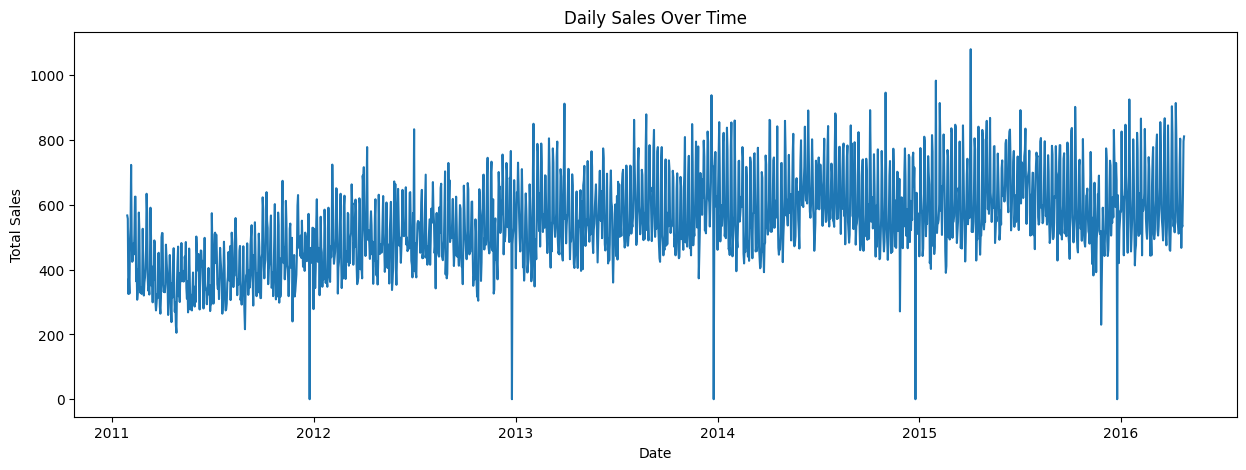

In [14]:
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Daily Sales Over Time')
plt.show()

Detect Trend

Trend slope: 130.9292811355312


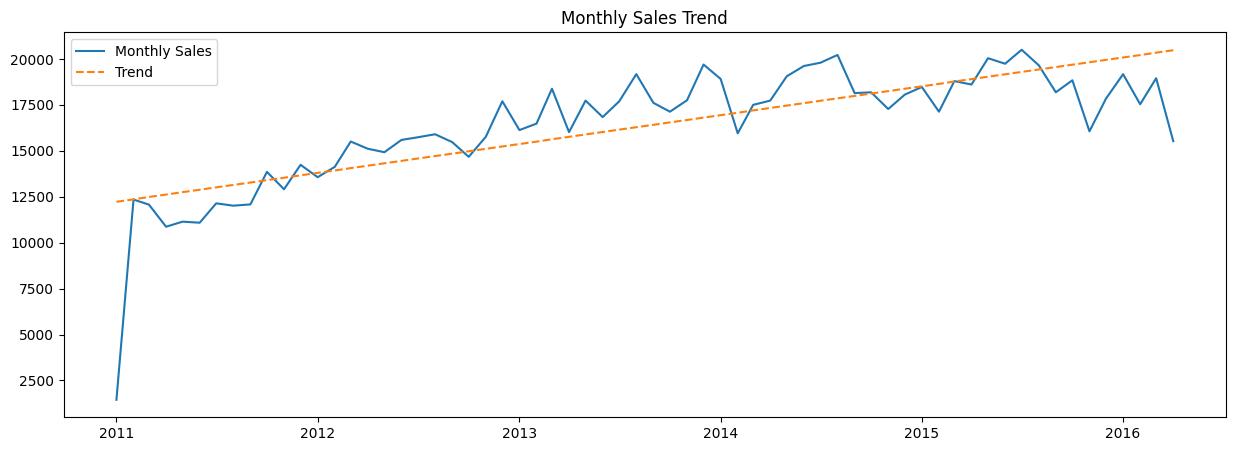

In [15]:
from sklearn.linear_model import LinearRegression

monthly_sales = df.groupby(df['date'].dt.to_period('M'))['sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

X = np.arange(len(monthly_sales)).reshape(-1, 1)
y = monthly_sales.values

trend_model = LinearRegression()
trend_model.fit(X, y)
slope = trend_model.coef_[0]

print("Trend slope:", slope)

plt.figure(figsize=(15, 5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales')
plt.plot(monthly_sales.index, trend_model.predict(X), label='Trend', linestyle='--')
plt.legend()
plt.title('Monthly Sales Trend')
plt.show()

Detect Seasonality

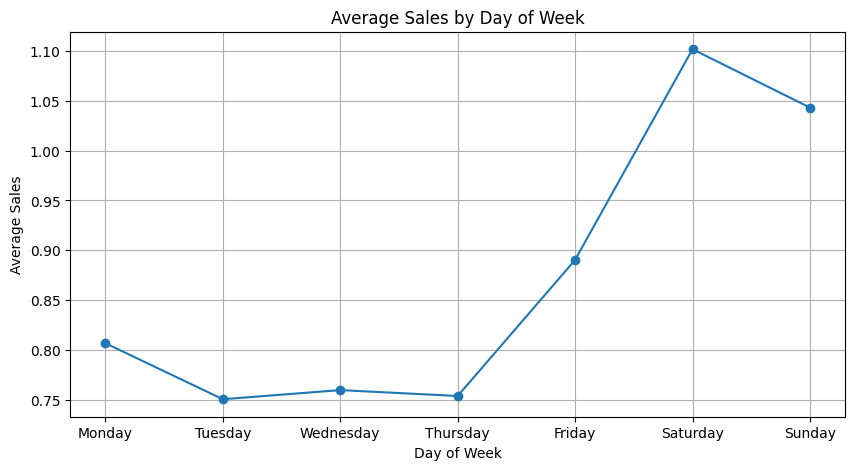

In [16]:
day_name = df['date'].dt.day_name()
weekly_pattern = df.groupby(day_name)['sales'].mean()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern = weekly_pattern.reindex(days_order)

plt.figure(figsize=(10, 5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker='o')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

Sales Analysis by Product

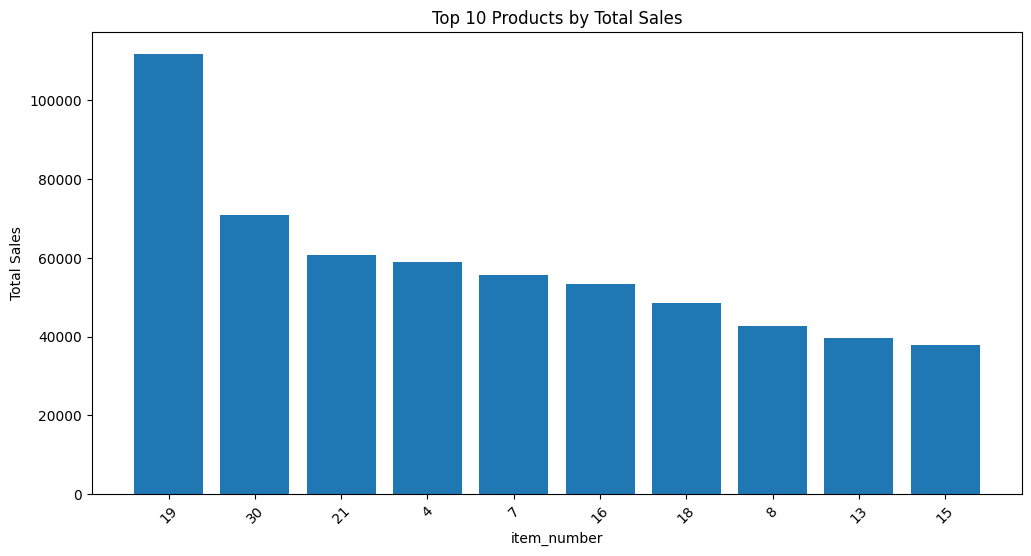

In [17]:
product_sales = df.groupby('item_number')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(product_sales.head(10).index.astype(str), product_sales.head(10).values)
plt.title('Top 10 Products by Total Sales')
plt.xlabel('item_number')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

Sales Analysis by Store

store_id
CA_1    446790.0
WI_1    306155.0
TX_1    293586.0
CA_2         0.0
CA_4         0.0
CA_3         0.0
TX_2         0.0
TX_3         0.0
WI_2         0.0
WI_3         0.0
Name: sales, dtype: float32


/tmp/ipykernel_59/3747249061.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_sales = df.groupby('store_id')['sales'].sum().sort_values(ascending=False)


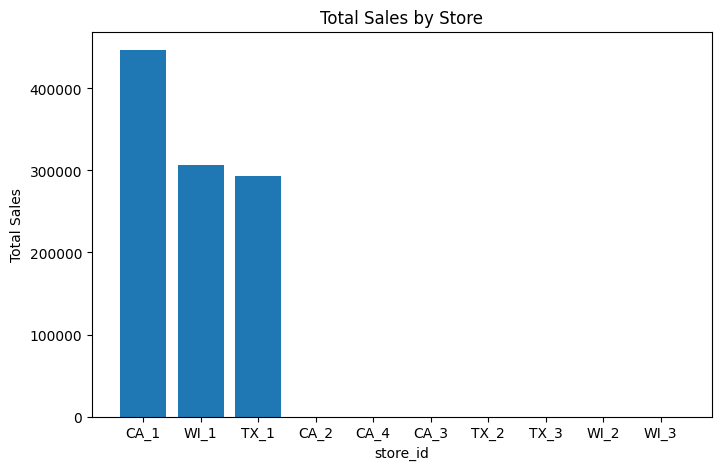

In [18]:
store_sales = df.groupby('store_id')['sales'].sum().sort_values(ascending=False)
print(store_sales)

plt.figure(figsize=(8, 5))
plt.bar(store_sales.index.astype(str), store_sales.values)
plt.title('Total Sales by Store')
plt.xlabel('store_id')
plt.ylabel('Total Sales')
plt.show()

Detect Outliers

Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 116878


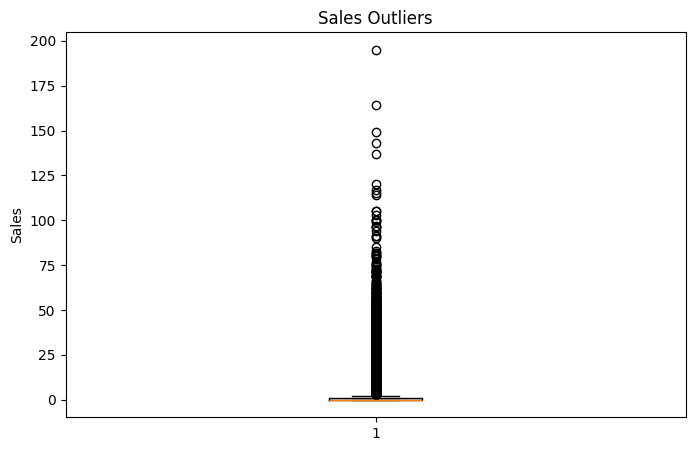

In [19]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['sales'] < lower_bound) | (df['sales'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

plt.figure(figsize=(8, 5))
plt.boxplot(df['sales'])
plt.title('Sales Outliers')
plt.ylabel('Sales')
plt.show()

Extract Key EDA Insights

In [20]:
print("Trend slope (monthly):", slope)
print("Highest average sales day:", weekly_pattern.idxmax())
print("Lowest average sales day:", weekly_pattern.idxmin())
print("Top selling product:", product_sales.idxmax())
print("Top selling store:", store_sales.idxmax())
print("Outlier rows:", len(outliers), "out of", len(df))

Trend slope (monthly): 130.9292811355312
Highest average sales day: Saturday
Lowest average sales day: Tuesday
Top selling product: 19
Top selling store: CA_1
Outlier rows: 116878 out of 1199451


# Stage 3 — Data Cleaning & Feature Engineering

Handle Missing Values

In [21]:
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print(df.isnull().sum().sum())

Series([], dtype: int64)
0


Handle Duplicates

In [22]:
before = df.shape[0]
df = df.drop_duplicates(subset=['store_id', 'item_number', 'date']).reset_index(drop=True)
after = df.shape[0]

print(before, "->", after)
print(before - after, "duplicate rows removed")

1199451 -> 172170
1027281 duplicate rows removed


Handle Outliers


We won't remove the high-sales rows, since they could be a genuine demand spike that the model needs to see. We'll just create a column to flag them for review.

In [23]:
df['is_sales_outlier'] = ((df['sales'] < lower_bound) | (df['sales'] > upper_bound)).astype('int8')
print(df['is_sales_outlier'].value_counts())

is_sales_outlier
0    145519
1     26651
Name: count, dtype: int64


Create day_of_week

In [24]:
df['day_of_week'] = df['date'].dt.dayofweek.astype('int8')
df[['date', 'day_of_week']].head()

,date,day_of_week
0,2011-01-29,5
1,2011-01-30,6
2,2011-01-31,0
3,2011-02-01,1
4,2011-02-02,2


Create month

In [25]:
df['month'] = df['date'].dt.month.astype('int8')
df[['date', 'month']].head()

,date,month
0,2011-01-29,1
1,2011-01-30,1
2,2011-01-31,1
3,2011-02-01,2
4,2011-02-02,2


Create year

In [26]:
df['year'] = df['date'].dt.year.astype('int16')
df[['date', 'year']].head()

,date,year
0,2011-01-29,2011
1,2011-01-30,2011
2,2011-01-31,2011
3,2011-02-01,2011
4,2011-02-02,2011


Create is_holiday

In [27]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['date'].min(), end=df['date'].max())
df['is_holiday'] = df['date'].dt.normalize().isin(holidays).astype('int8')

print(df['is_holiday'].value_counts())

is_holiday
0    167580
1      4590
Name: count, dtype: int64


Create time_idx

In [28]:
df['time_idx'] = (df['date'] - df['date'].min()).dt.days.astype('int32')
df[['date', 'time_idx']].head()

,date,time_idx
0,2011-01-29,0
1,2011-01-30,1
2,2011-01-31,2
3,2011-02-01,3
4,2011-02-02,4


Prepare the target = demand/sales

In [29]:
df['target'] = df['sales']
df[['date', 'store_id', 'item_number', 'sales', 'target']].head()

,date,store_id,item_number,sales,target
0,2011-01-29,CA_1,1,3.0,3.0
1,2011-01-30,CA_1,1,0.0,0.0
2,2011-01-31,CA_1,1,0.0,0.0
3,2011-02-01,CA_1,1,1.0,1.0
4,2011-02-02,CA_1,1,4.0,4.0


Confirm No Data Leakage

In [30]:
known_reals_preview = [
    'time_idx', 'month', 'year', 'day', 'is_holiday', 'is_weekend',
    'snap', 'is_event', 'event_count', 'event_impact', 'wday_x_snap', 'sell_price'
]
unknown_reals_preview = ['lag_1', 'lag_7', 'target']

print('target' in known_reals_preview)
print(set(known_reals_preview) & set(unknown_reals_preview))

False
set()


# Stage 4 — Preparing TFT Data

Define Group IDs

In [31]:
for col in ['store_id', 'item_category', 'item_subcategory', 'item_number', 'day_of_week']:
    df[col] = df[col].astype(str)

group_ids = ['store_id', 'item_number']

Define Static Features

In [32]:
static_categoricals = [
    'store_id',
    'item_category',
    'item_subcategory',
    'item_number',
]

Define Time-varying Features

In [33]:
time_varying_known_categoricals = ['day_of_week']

time_varying_known_reals = [
    'time_idx', 'month', 'year', 'day', 'is_holiday', 'is_weekend',
    'snap', 'is_event', 'event_count', 'event_impact', 'wday_x_snap', 'sell_price'
]

time_varying_unknown_reals = ['target', 'lag_1', 'lag_7']

Define Target

In [34]:
target = 'target'

max_encoder_length = 24

In [35]:
max_encoder_length = MAX_ENCODER_LENGTH
print(max_encoder_length)

24


 max_prediction_length = 6

In [36]:
max_prediction_length = MAX_PREDICTION_LENGTH
print(max_prediction_length)

6


### تأكيد قبل بناء الداتاسيت

In [37]:
print(df.shape)
print(df['item_number'].nunique(), "products")
print(df['store_id'].nunique(), "stores")

assert df['item_number'].nunique() <= N_ITEMS, f"Expected at most {N_ITEMS} products, found {df['item_number'].nunique()}"
assert df.shape[0] < 500_000, f"df too large: {df.shape[0]} rows, check filtering steps above"

(172170, 27)
30 products
3 stores


Create TimeSeriesDataSet

In [38]:
!pip install -q --no-deps "lightning<2.6" pytorch-forecasting kagglehub

In [39]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [40]:
!pip install -q --no-deps pytorch-forecasting lightning kagglehub

In [41]:
import torch
print(torch.__version__)

2.10.0+cu128


In [42]:
!pip uninstall -y pytorch-forecasting
!pip install "pytorch-forecasting==1.7.0"

Found existing installation: pytorch-forecasting 1.8.0
Uninstalling pytorch-forecasting-1.8.0:
  Successfully uninstalled pytorch-forecasting-1.8.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 11.3 MB/s eta 0:00:00


In [43]:
from pytorch_forecasting import TimeSeriesDataSet

training_cutoff = df['time_idx'].max() - max_prediction_length

training = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx='time_idx',
    target=target,
    group_ids=group_ids,
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=static_categoricals,
    time_varying_known_categoricals=time_varying_known_categoricals,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    allow_missing_timesteps=True,
)

print(len(training))

169020


Create Train / Validation

In [44]:
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

print(len(training), "training samples")
print(len(validation), "validation samples")

169020 training samples
90 validation samples


Create DataLoaders

In [45]:
train_dataloader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print(len(train_dataloader), "train batches")
print(len(val_dataloader), "validation batches")

2640 train batches
2 validation batches


Confirm Batches Work Correctly

In [46]:
x, y = next(iter(train_dataloader))
print(x['encoder_cont'].shape)
print(x['decoder_cont'].shape)
print(y[0].shape)

torch.Size([64, 24, 15])
torch.Size([64, 6, 15])
torch.Size([64, 6])


Stage 5 — Training TFT

TFT model (Quantile Loss / Learning Rate / Hidden Size / Attention Heads)

In [47]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    output_size=7,
    reduce_on_plateau_patience=3,
)

print(sum(p.numel() for p in tft.parameters()), "parameters")

34041 parameters


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Train the Model (CPU only)

In [48]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5,
    mode='min'
)

checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints',
    filename='best-tft',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, checkpoint_callback],
    enable_model_summary=False,
    logger=False,
    enable_progress_bar=True,
    limit_val_batches=1.0,
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [49]:
best_model_path = checkpoint_callback.best_model_path
print(best_model_path)

best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

/kaggle/working/checkpoints/best-tft.ckpt


# Stage 6 — Evaluation

Run Predictions on Validation

In [50]:
gc.collect()

prediction_result = best_tft.predict(
    validation,
    mode='prediction',
    batch_size=16,
    num_workers=0,
    return_index=True,
    return_y=True,
)

predictions = prediction_result.output
index_df = prediction_result.index
actuals = prediction_result.y[0]

print(predictions.shape)
print(actuals.shape)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


torch.Size([90, 6])
torch.Size([90, 6])


Calculate MAE / RMSE / MAPE

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = actuals.detach().cpu().numpy().flatten()
y_pred = predictions.detach().cpu().numpy().flatten()
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

nonzero_mask = y_true != 0
mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("SMAPE:", smape)

MAE: 0.17533661425113678
RMSE: 0.48026744378047065
MAPE: 14.57675
SMAPE: 104.44215


In [53]:
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
print("WAPE:", wape)

WAPE: 11.139031


In [54]:
print(y_true.mean())
print(y_true.std())
print((y_true == 0).sum() / len(y_true) * 100, "% of days have zero sales")

1.574074
3.2352335
50.0 % of days have zero sales


Compare Actual vs Forecast

In [56]:
comparison_rows = []
for i in range(predictions.shape[0]):
    info = index_df.iloc[i]
    for h in range(predictions.shape[1]):
        comparison_rows.append({
            'store_id': info['store_id'],
            'item_number': info['item_number'],
            'time_idx': info['time_idx'] + h,
            'actual': float(actuals[i, h]),
            'forecast': float(predictions[i, h]),
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.head(20)

,store_id,item_number,time_idx,actual,forecast
0,CA_1,1,1907,1.0,1.068998
1,CA_1,1,1908,1.0,1.049282
2,CA_1,1,1909,0.0,-0.008312
3,CA_1,1,1910,1.0,1.043952
4,CA_1,1,1911,1.0,1.221140
5,CA_1,1,1912,0.0,-0.000143
6,CA_1,10,1907,0.0,-0.026142
7,CA_1,10,1908,0.0,-0.024027
8,CA_1,10,1909,0.0,-0.020989
9,CA_1,10,1910,0.0,-0.018959


Plot Forecast vs Actual

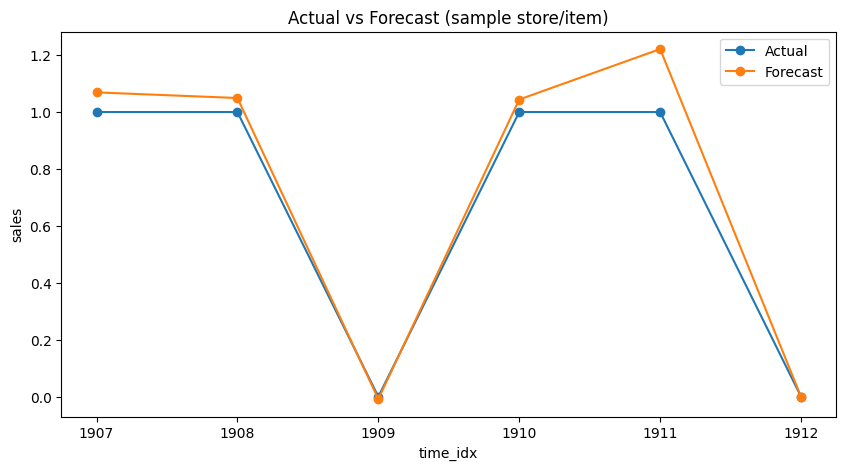

In [57]:
sample_pair = comparison_df[
    (comparison_df['store_id'] == comparison_df['store_id'].iloc[0]) &
    (comparison_df['item_number'] == comparison_df['item_number'].iloc[0])
].sort_values('time_idx')

plt.figure(figsize=(10, 5))
plt.plot(sample_pair['time_idx'], sample_pair['actual'], marker='o', label='Actual')
plt.plot(sample_pair['time_idx'], sample_pair['forecast'], marker='o', label='Forecast')
plt.legend()
plt.title('Actual vs Forecast (sample store/item)')
plt.xlabel('time_idx')
plt.ylabel('sales')
plt.show()

Evaluate whether the model is acceptable or needs tuning

In [58]:
print("MAE:", mae)
print("RMSE:", rmse)
print("SMAPE:", smape)
print("Average actual sales:", y_true.mean())
print("MAE as % of average sales:", (mae / y_true.mean()) * 100)

MAE: 0.17533661425113678
RMSE: 0.48026744378047065
SMAPE: 104.44215
Average actual sales: 1.574074
MAE as % of average sales: 11.139032


# Stage 7 — Forecasting

Input the last 24 days and predict the next 6 days

In [59]:
future_prediction_result = best_tft.predict(
    validation,
    mode='prediction',
    batch_size=16,
    num_workers=0,
    return_index=True,
)

future_predictions = future_prediction_result.output
future_index_df = future_prediction_result.index

print(future_predictions.shape)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider inc

torch.Size([90, 6])


Output the forecast per product/store and prepare the final table

In [60]:
forecast_rows = []
for i in range(future_predictions.shape[0]):
    info = future_index_df.iloc[i]
    for h in range(future_predictions.shape[1]):
        forecast_rows.append({
            'store_id': info['store_id'],
            'item_number': info['item_number'],
            'time_idx': info['time_idx'] + h,
            'predicted_demand': float(future_predictions[i, h]),
        })

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.head(20)

,store_id,item_number,time_idx,predicted_demand
0,CA_1,1,1907,1.068998
1,CA_1,1,1908,1.049282
2,CA_1,1,1909,-0.008312
3,CA_1,1,1910,1.043952
4,CA_1,1,1911,1.221140
5,CA_1,1,1912,-0.000143
6,CA_1,10,1907,-0.026142
7,CA_1,10,1908,-0.024027
8,CA_1,10,1909,-0.020989
9,CA_1,10,1910,-0.018959


# Stage 8 — Delivering the Forecast to the Next Step

Save the forecast as CSV/Excel

In [61]:
forecast_df.to_csv('forecast.csv', index=False)
forecast_df.to_excel('forecast.xlsx', index=False)
print("saved forecast.csv and forecast.xlsx")

saved forecast.csv and forecast.xlsx


Determine the predicted demand

In [62]:
forecast_summary = forecast_df.groupby(['store_id', 'item_number'])['predicted_demand'].sum().reset_index()
forecast_summary = forecast_summary.rename(columns={'predicted_demand': 'predicted_demand_next_6_days'})
forecast_summary.head(20)

,store_id,item_number,predicted_demand_next_6_days
0,CA_1,1,4.374918
1,CA_1,10,1.883158
2,CA_1,11,11.281272
3,CA_1,12,20.540095
4,CA_1,13,16.581327
5,CA_1,14,5.101244
6,CA_1,15,6.182665
7,CA_1,16,0.000002
8,CA_1,17,8.141931
9,CA_1,18,71.942487


Hand off results to Replenishment / Order Quantity and link to the AI Agent

In [63]:
print(forecast_df.shape)
print(forecast_summary.shape)
forecast_summary.sort_values('predicted_demand_next_6_days', ascending=False).head(10)

(540, 4)
(90, 3)


,store_id,item_number,predicted_demand_next_6_days
69,WI_1,18,90.609251
10,CA_1,19,84.090755
9,CA_1,18,71.942487
39,TX_1,18,43.963659
70,WI_1,19,39.732388
33,TX_1,12,38.048030
85,WI_1,5,24.135885
63,WI_1,12,24.027080
80,WI_1,28,22.341381
3,CA_1,12,20.540095
